# 🧠 CranioVision — Complete Clinical Pipeline (3-Model Ensemble)

The **real** CranioVision demonstration. Runs the entire clinical pipeline on one case using **all three trained models**:

1. **3-model ensemble inference** — weighted soft voting across Attention U-Net, SwinUNETR, nnU-Net
2. **Model agreement analysis** — where do models agree vs disagree?
3. **MC Dropout uncertainty** — per-voxel confidence
4. **Grad-CAM explainability** — what the model attends to
5. **Clinical report + 16-panel visualization**

**Memory-efficient:** Never holds more than 1 model on the GPU at a time. Works on 4GB GTX 1650.

**Runtime:** ~30-35 min on GTX 1650
- Ensemble (3 sequential model loads + predict + free): ~10 min
- MC Dropout (5 samples on Attention U-Net): ~5 min
- Grad-CAM: ~2 min
- Visualization: instant

## 1. Setup

In [1]:
import sys
import json
import gc
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import torch

from src.cranovision.config import (
    MODELS_DIR, OUTPUTS_DIR, CLASS_NAMES, DEVICE, USE_AMP, PATCH_SIZE,
)
from src.cranovision.data import get_splits, get_val_transforms
from src.cranovision.inference import (
    load_model,
    compute_agreement,
    weights_from_val_dice,
    mc_dropout_predict,
    summarize_confidence,
    compute_grad_cam,
    compute_region_volumes,
    make_inferer,
)
from src.cranovision.training.metrics import (
    compute_case_dice,
    compute_brats_region_dice,
)

print('✅ Imports ok')

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


✅ Imports ok


In [2]:
# ── Configuration ──
CASE_IDX      = 0       # which test case (0-29)
N_MC_SAMPLES  = 5       # MC Dropout passes

# Helper to fully clear GPU memory between stages
def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, 'reset_peak_memory_stats'):
        torch.cuda.reset_peak_memory_stats()

def gpu_mem_mb():
    return torch.cuda.memory_allocated() / 1e6 if torch.cuda.is_available() else 0

print(f'Initial GPU memory: {gpu_mem_mb():.1f} MB allocated')

Initial GPU memory: 0.0 MB allocated


In [3]:
# Load val Dice from each history JSON (for Dice-proportional ensemble weights)
def load_val_dice(model_names=('attention_unet', 'swin_unetr', 'nnunet')):
    val_dice = {}
    for name in model_names:
        hist_path = OUTPUTS_DIR / f'{name}_history.json'
        if hist_path.exists():
            with open(hist_path, 'r') as f:
                hist = json.load(f)
            val_dice[name] = float(hist.get('best_dice', 1.0))
        else:
            print(f'⚠ No history JSON for {name}')
            val_dice[name] = None
    return val_dice

VAL_DICE = load_val_dice()
print('\nValidation Dice (from history JSONs):')
for name, d in VAL_DICE.items():
    print(f'  {name:<18}: {d if d is not None else "not found"}')


Validation Dice (from history JSONs):
  attention_unet    : 0.7642461061477661
  swin_unetr        : 0.8219107985496521
  nnunet            : 0.7562064528465271


In [4]:
# Pick case
_, _, test_cases = get_splits()
case = test_cases[CASE_IDX]
CASE_ID = case['case_id']
print(f'\nTarget case: {CASE_ID}')

Scanning 200 patient folders in BraTS2024_small_dataset/
  Valid cases: 200
Loading existing split from data_split.json
  Train: 140 (70%) | Val: 30 (15%) | Test: 30 (15%)

Target case: BraTS-GLI-02196-105


## 2. Stage 1 — Ensemble inference (one model at a time)

Loads each model, runs prediction, stores softmax probs on CPU, frees GPU. Never holds more than 1 model in memory at a time — crucial for 4GB GPU.

In [5]:
# Model registry — what to load and how
MODEL_REGISTRY = {
    'attention_unet': {
        'ckpt': 'attention_unet_best.pth',
        'build_kwargs': {},
    },
    'swin_unetr': {
        'ckpt': 'swin_unetr_best.pth',
        'build_kwargs': {'feature_size': 48, 'use_checkpoint': False},
    },
    'nnunet': {
        'ckpt': 'nnunet_best.pth',
        'build_kwargs': {
            'filters': (32, 64, 128, 256, 320, 320),
            'deep_supervision': False,
        },
    },
}

# Filter to only models with existing checkpoints
available_models = {
    name: cfg for name, cfg in MODEL_REGISTRY.items()
    if (MODELS_DIR / cfg['ckpt']).exists()
}
print(f'Available models: {list(available_models.keys())}')

assert len(available_models) >= 2, 'Need at least 2 model checkpoints for ensemble'

Available models: ['attention_unet', 'swin_unetr', 'nnunet']


In [6]:
# Compute ensemble weights from val Dice
weight_input = {}
for name in available_models:
    val = VAL_DICE.get(name)
    if val is None:
        print(f'  ⚠ {name} has no val Dice — using 1.0 (equal weight)')
        val = 1.0
    weight_input[name] = val

weights = weights_from_val_dice(weight_input)

print('\n✓ Ensemble weights (Dice-proportional):')
for name, w in weights.items():
    print(f'  {name:<18}: {w:.4f}  (val Dice {weight_input[name]:.4f})')


✓ Ensemble weights (Dice-proportional):
  attention_unet    : 0.3263  (val Dice 0.7642)
  swin_unetr        : 0.3509  (val Dice 0.8219)
  nnunet            : 0.3228  (val Dice 0.7562)


In [7]:
# ── Memory-efficient ensemble: load → predict → save probs on CPU → free ──

# Preprocess the case ONCE (shared across all models)
transforms = get_val_transforms()
sample = transforms(case)
full_image_cpu = sample['image']                        # (4, D, H, W) on CPU
gt = sample['label'].squeeze(0).cpu()                   # (D, H, W)

inferer = make_inferer()
per_model_probs = {}     # name -> (C, D, H, W) softmax probs on CPU
per_model_preds = {}     # name -> (D, H, W) argmax on CPU

for name, cfg in available_models.items():
    print(f'\n▸ Loading {name}...')
    model = load_model(name, MODELS_DIR / cfg['ckpt'], **cfg['build_kwargs'])
    print(f'  GPU after load: {gpu_mem_mb():.1f} MB')

    print(f'  Running inference...')
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            image_gpu = full_image_cpu.unsqueeze(0).to(DEVICE)
            logits = inferer(image_gpu, model)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().float()
        pred  = probs.argmax(dim=0)

    per_model_probs[name] = probs
    per_model_preds[name] = pred

    # Free everything from GPU
    del model, logits, image_gpu
    free_gpu()
    print(f'  ✓ {name} done. GPU after free: {gpu_mem_mb():.1f} MB')

print(f'\n✓ All {len(per_model_probs)} models inferred.')

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.



▸ Loading attention_unet...
Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 97.2 MB
  Running inference...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  ✓ attention_unet done. GPU after free: 0.0 MB

▸ Loading swin_unetr...
Loading swin_unetr from swin_unetr_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 257.3 MB
  Running inference...
  ✓ swin_unetr done. GPU after free: 33.6 MB

▸ Loading nnunet...
Loading nnunet from nnunet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 161.6 MB
  Running inference...
  ✓ nnunet done. GPU after free: 33.6 MB

✓ All 3 models inferred.


In [8]:
# Weighted soft voting on CPU
weighted_sum = None
for name, probs in per_model_probs.items():
    w = weights[name]
    if weighted_sum is None:
        weighted_sum = w * probs
    else:
        weighted_sum += w * probs

ensemble_pred  = weighted_sum.argmax(dim=0)
ensemble_probs = weighted_sum

# Metrics
ens_dice  = compute_case_dice(ensemble_pred, gt)
ens_brats = compute_brats_region_dice(ensemble_pred, gt)
ens_volumes  = compute_region_volumes(ensemble_pred)
true_volumes = compute_region_volumes(gt)

# Per-model metrics
per_model_dice = {name: compute_case_dice(p, gt) for name, p in per_model_preds.items()}
per_model_brats = {name: compute_brats_region_dice(p, gt) for name, p in per_model_preds.items()}

print(f'✓ Ensemble prediction ready')
print(f'  Ensemble mean Dice: {np.mean(ens_dice):.4f}')
print(f'  Per-model means   :')
for name, d in per_model_dice.items():
    print(f'    {name:<18}: {np.mean(d):.4f}')

✓ Ensemble prediction ready
  Ensemble mean Dice: 0.9117
  Per-model means   :
    attention_unet    : 0.8201
    swin_unetr        : 0.9067
    nnunet            : 0.8862


## 3. Stage 2 — Agreement analysis

In [9]:
agreement = compute_agreement(per_model_preds)
print(f'Unanimous voxels   : {agreement["unanimous_fraction"]*100:.2f}% of volume')
print(f'Disagreement voxels: {agreement["disagreement_mask"].sum().item():,}')

Unanimous voxels   : 98.41% of volume
Disagreement voxels: 78,296


## 4. Stage 3 — MC Dropout uncertainty (Attention U-Net)

Uses Attention U-Net (lightest model, fits in 4GB with grad-off repeated passes).

In [10]:
UNCERTAINTY_MODEL_NAME = 'attention_unet'

print(f'Loading {UNCERTAINTY_MODEL_NAME} for MC Dropout...')
mc_model = load_model(UNCERTAINTY_MODEL_NAME, MODELS_DIR / 'attention_unet_best.pth')
print(f'  GPU after load: {gpu_mem_mb():.1f} MB')

print(f'\nRunning {N_MC_SAMPLES} stochastic forward passes...')
mc_result = mc_dropout_predict(
    model=mc_model,
    case_dict=case,
    n_samples=N_MC_SAMPLES,
    inferer=inferer,
    verbose=True,
)

confidence = summarize_confidence(mc_result, uncertain_threshold=0.15)

# Free MC Dropout model
del mc_model
free_gpu()
print(f'\n✓ MC Dropout done. GPU after free: {gpu_mem_mb():.1f} MB')
print(f'  Mean confidence    : {confidence["mean_confidence"]:.4f}')
print(f'  Uncertain fraction : {confidence["uncertain_fraction"]*100:.2f}%')

Loading attention_unet for MC Dropout...
Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 130.8 MB

Running 5 stochastic forward passes...
MC Dropout active — 18 dropout layers enabled
Running 5 stochastic forward passes...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  Sample  1/5
  Sample  2/5
  Sample  3/5
  Sample  4/5
  Sample  5/5

✓ MC Dropout done. GPU after free: 33.6 MB
  Mean confidence    : 0.9764
  Uncertain fraction : 0.13%


## 5. Stage 4 — Grad-CAM explainability (Attention U-Net)

Same lightweight model. Grad-CAM needs gradient storage → only Attention U-Net fits on 4GB.

In [11]:
GRADCAM_MODEL_NAME = 'attention_unet'

print(f'Loading {GRADCAM_MODEL_NAME} for Grad-CAM...')
cam_model = load_model(GRADCAM_MODEL_NAME, MODELS_DIR / 'attention_unet_best.pth')
print(f'  GPU after load: {gpu_mem_mb():.1f} MB')

print(f'\nRunning Grad-CAM on {GRADCAM_MODEL_NAME}...')
cam_result = compute_grad_cam(
    model=cam_model,
    case_dict=case,
    model_name=GRADCAM_MODEL_NAME,
    target_classes=(1, 2, 3),
    use_predicted_mask=True,
    verbose=True,
)

# Free Grad-CAM model
del cam_model
free_gpu()
print(f'\n✓ Grad-CAM done. GPU after free: {gpu_mem_mb():.1f} MB')

Loading attention_unet for Grad-CAM...
Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 130.8 MB

Running Grad-CAM on attention_unet...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Tumor centroid (z, y, x): (83, 139, 106)
Patch offset (z0, y0, x0): (19, 64, 32)
Patch shape             : (4, 128, 128, 128)
Target layer: Conv3d
  → Generating heatmap for class 1 (Edema)
  → Generating heatmap for class 2 (Enhancing tumor)
  → Generating heatmap for class 3 (Necrotic core)

✓ Grad-CAM done. GPU after free: 33.6 MB


## 6. Clinical report

In [12]:
print('╔' + '═' * 78 + '╗')
print(f'║  CRANIOVISION CLINICAL REPORT — 3-MODEL ENSEMBLE{" " * 30}║')
print(f'║  Case: {CASE_ID:<70}║')
print('╚' + '═' * 78 + '╝')

print('\n▸ ENSEMBLE CONFIGURATION')
for name, w in weights.items():
    print(f'  {name.replace("_", " ").title():<22} | weight {w:.3f} | val Dice {weight_input[name]:.4f}')

print('\n▸ SEGMENTATION RESULTS (Dice vs ground truth)')
print(f'  {"Model":<20}{"Mean":>9}{"Edema":>9}{"Enhancing":>11}{"Necrotic":>10}')
print(f'  {"-" * 58}')
for name, dice in per_model_dice.items():
    display = name.replace('_', ' ').title()
    print(f'  {display:<20}{np.mean(dice):>9.4f}{dice[0]:>9.4f}{dice[1]:>11.4f}{dice[2]:>10.4f}')
print(f'  {"-" * 58}')
print(f'  {"ENSEMBLE":<20}{np.mean(ens_dice):>9.4f}'
      f'{ens_dice[0]:>9.4f}{ens_dice[1]:>11.4f}{ens_dice[2]:>10.4f}  ← final')

best_single = max([np.mean(d) for d in per_model_dice.values()])
improvement = np.mean(ens_dice) - best_single
sign = '+' if improvement >= 0 else ''
print(f'\n  Improvement over best single model: {sign}{improvement:.4f} Dice')

print('\n▸ VOLUMES (ensemble prediction)')
print(f'  {"Region":<22}{"Predicted":>15}{"Ground truth":>15}')
for name in CLASS_NAMES[1:]:
    print(f'  {name:<22}{ens_volumes[name]:>13.2f}  {true_volumes[name]:>13.2f} cm³')
print(f'  {"-" * 50}')
print(f'  {"Total tumor":<22}{ens_volumes["Total tumor"]:>13.2f}  {true_volumes["Total tumor"]:>13.2f} cm³')

print('\n▸ BraTS STANDARD REGIONS (ensemble)')
print(f'  Whole Tumor (WT) : {ens_brats["WT"]:.4f}')
print(f'  Tumor Core  (TC) : {ens_brats["TC"]:.4f}')
print(f'  Enhancing   (ET) : {ens_brats["ET"]:.4f}')

print(f'\n▸ MODEL AGREEMENT')
print(f'  Unanimous voxels   : {agreement["unanimous_fraction"]*100:.2f}% of volume')
print(f'  Voxels in disagreement: {agreement["disagreement_mask"].sum().item():,}')

print(f'\n▸ UNCERTAINTY ({UNCERTAINTY_MODEL_NAME}, {N_MC_SAMPLES} MC Dropout samples)')
print(f'  Overall confidence : {confidence["mean_confidence"]:.4f}')
print(f'  Uncertain fraction : {confidence["uncertain_fraction"]*100:.2f}%')

if confidence['mean_confidence'] >= 0.90 and agreement['unanimous_fraction'] >= 0.95:
    verdict = '✓ HIGH CONFIDENCE — all models agree, uncertainty low'
elif confidence['mean_confidence'] >= 0.75:
    verdict = '~ MODERATE CONFIDENCE — review boundary regions'
else:
    verdict = '⚠ LOW CONFIDENCE — mandatory radiologist review'

print(f'\n▸ VERDICT')
print(f'  {verdict}')
print('─' * 80)

╔══════════════════════════════════════════════════════════════════════════════╗
║  CRANIOVISION CLINICAL REPORT — 3-MODEL ENSEMBLE                              ║
║  Case: BraTS-GLI-02196-105                                                   ║
╚══════════════════════════════════════════════════════════════════════════════╝

▸ ENSEMBLE CONFIGURATION
  Attention Unet         | weight 0.326 | val Dice 0.7642
  Swin Unetr             | weight 0.351 | val Dice 0.8219
  Nnunet                 | weight 0.323 | val Dice 0.7562

▸ SEGMENTATION RESULTS (Dice vs ground truth)
  Model                    Mean    Edema  Enhancing  Necrotic
  ----------------------------------------------------------
  Attention Unet         0.8201   0.8737     0.8860    0.7006
  Swin Unetr             0.9067   0.9108     0.9084    0.9008
  Nnunet                 0.8862   0.8564     0.9125    0.8896
  ----------------------------------------------------------
  ENSEMBLE               0.9117   0.9168     0.9155    0.9

## 7. Unified 16-panel visualization

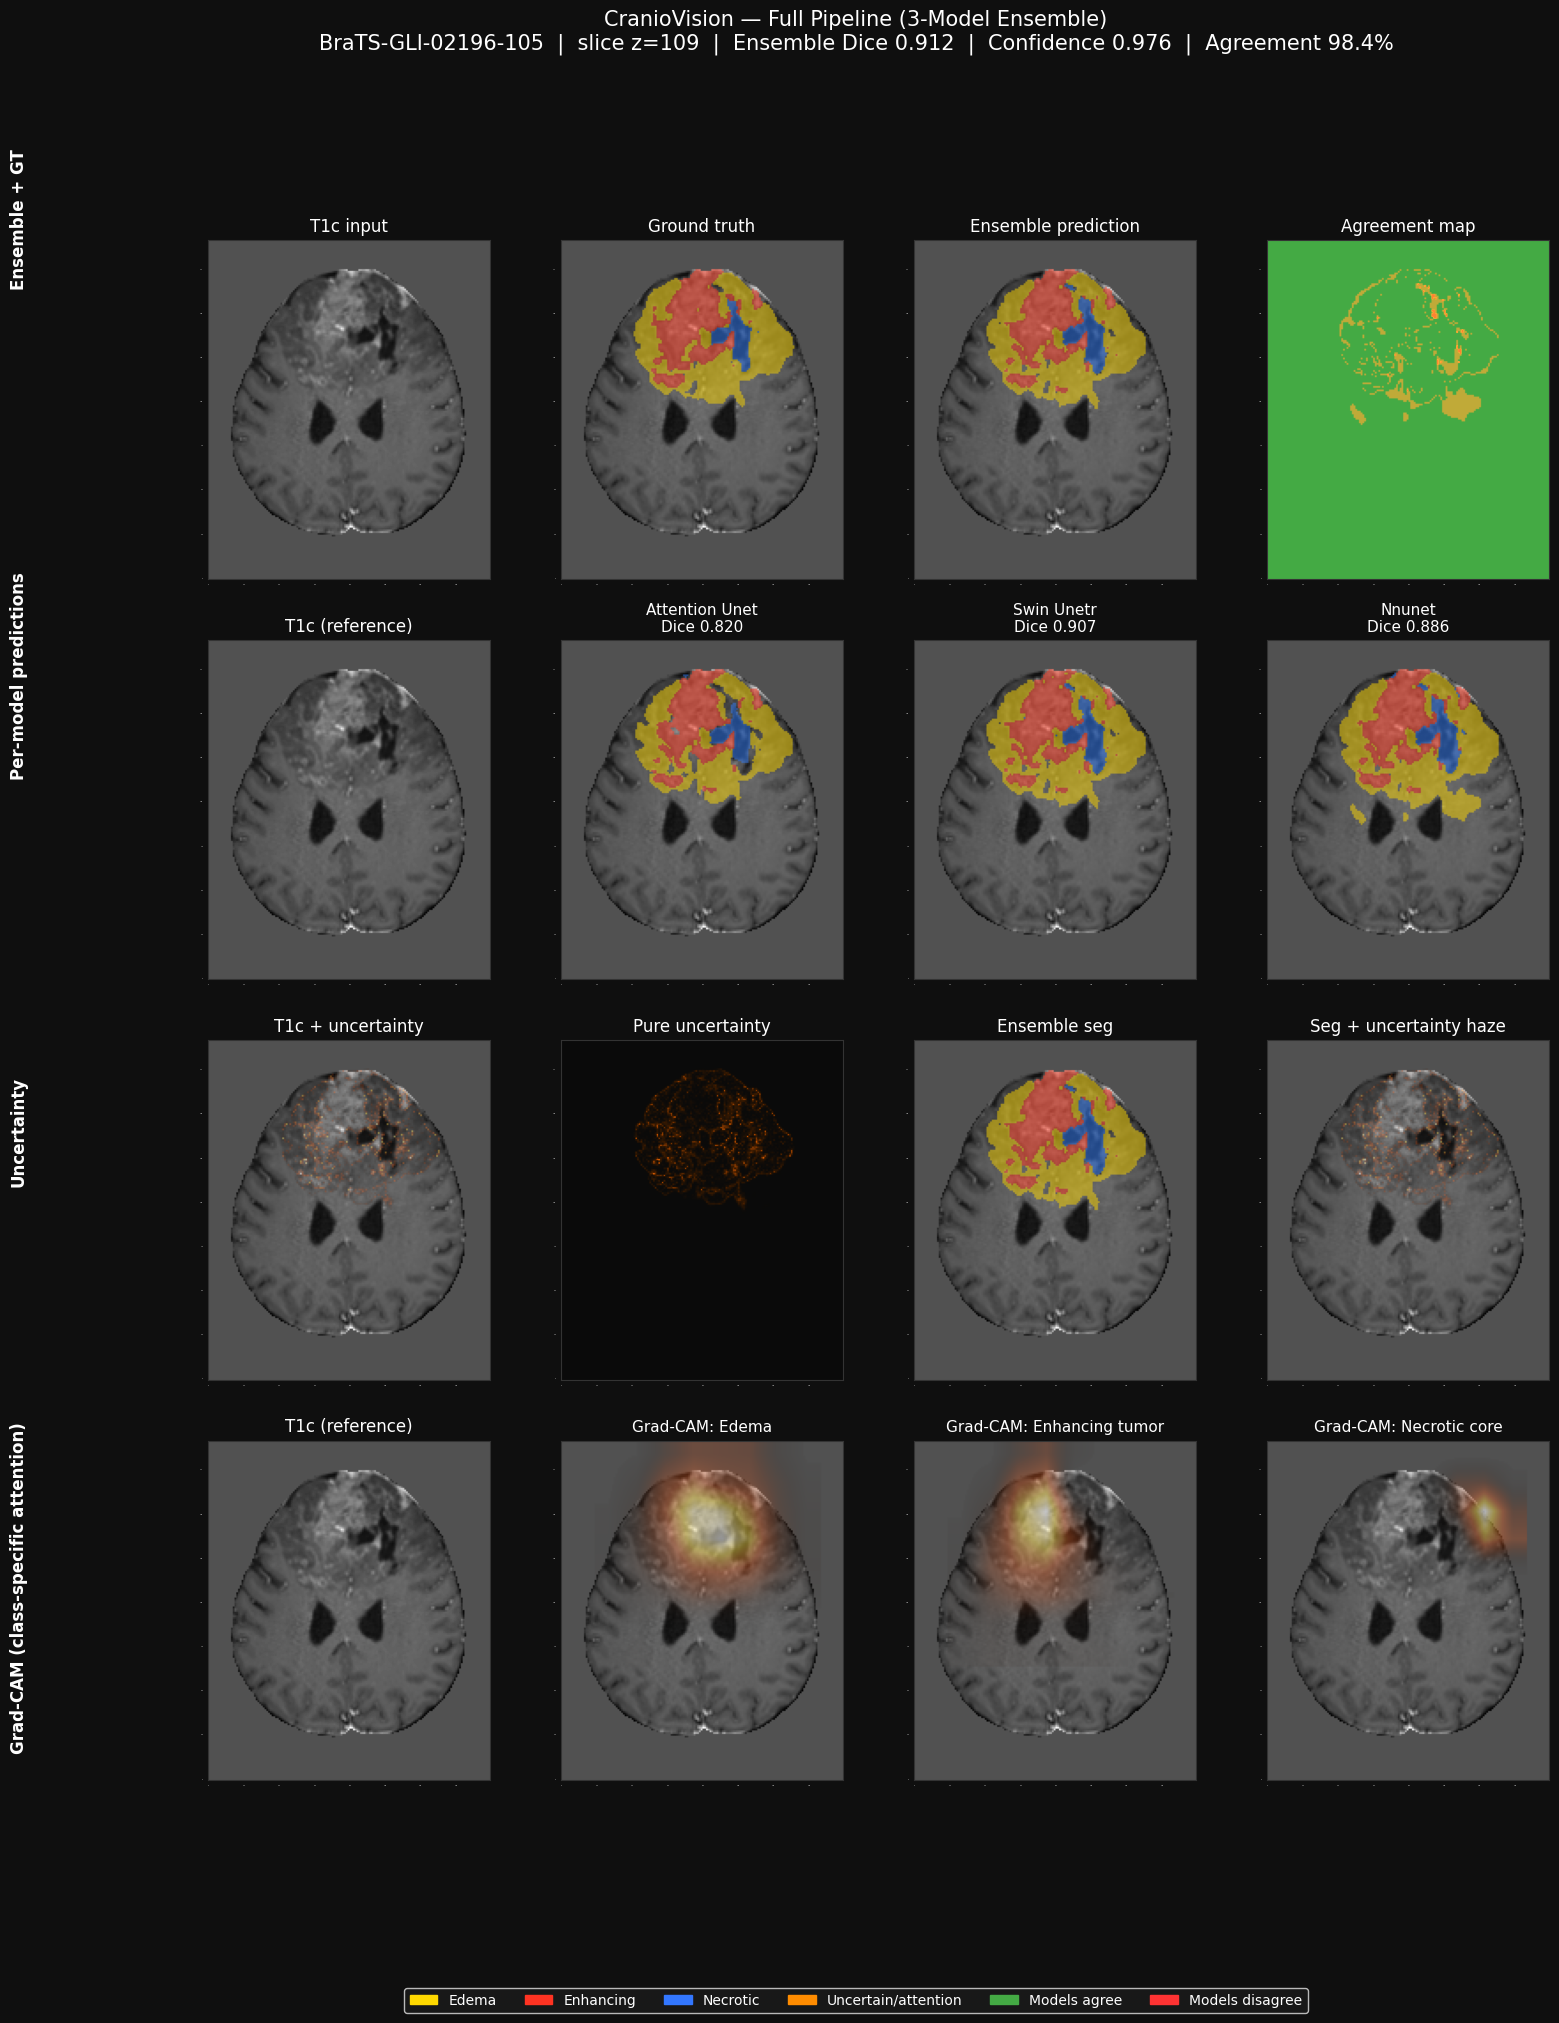


✅ Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\full_demo_BraTS-GLI-02196-105.png


In [13]:
unc_cmap = LinearSegmentedColormap.from_list(
    'uncertainty', ['#0a0a0a', '#3a1a00', '#cc5500', '#ffaa33', '#ffffff'])
gradcam_cmap = LinearSegmentedColormap.from_list(
    'gradcam', ['#0a0a0a', '#331100', '#aa3300', '#ff6622', '#ffdd44', '#ffffff'])
agreement_cmap = LinearSegmentedColormap.from_list(
    'agreement', ['#ff3333', '#ffaa33', '#44aa44'])

def overlay_seg(mri, seg):
    mri_n = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_n, mri_n, mri_n], axis=-1)
    colors = {1: [1.0, 0.85, 0], 2: [1.0, 0.2, 0.1], 3: [0.2, 0.5, 1.0]}
    for lbl, color in colors.items():
        m = seg == lbl
        if m.any():
            rgb[m] = 0.5 * rgb[m] + 0.5 * np.array(color)
    return np.clip(rgb, 0, 1)

def overlay_heatmap(mri, hm, alpha=0.55):
    mri_n = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_n, mri_n, mri_n], axis=-1)
    hm_n = hm / (hm.max() + 1e-8)
    colored = gradcam_cmap(hm_n)[..., :3]
    mask = hm_n > 0.05
    for c in range(3):
        rgb[..., c] = np.where(mask,
                                (1 - alpha * hm_n) * rgb[..., c] + alpha * hm_n * colored[..., c],
                                rgb[..., c])
    return np.clip(rgb, 0, 1)

# Find best slice
pred_np = ensemble_pred.numpy()
tumor_per_slice = (pred_np > 0).sum(axis=(0, 1))
TARGET_SLICE = int(tumor_per_slice.argmax())

# Extract slices
img_slice   = full_image_cpu[1, :, :, TARGET_SLICE].numpy().T
gt_slice    = gt.numpy()[:, :, TARGET_SLICE].T
ens_slice   = pred_np[:, :, TARGET_SLICE].T
agree_slice = agreement['agreement_map'].numpy()[:, :, TARGET_SLICE].T
unc_slice   = mc_result['uncertainty'].numpy()[:, :, TARGET_SLICE].T
per_model_slices = {
    name: p.numpy()[:, :, TARGET_SLICE].T
    for name, p in per_model_preds.items()
}
img_n = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor('#0f0f0f')
gs = fig.add_gridspec(4, 4, hspace=0.18, wspace=0.05)

# ROW 1: Input | GT | Ensemble | Agreement
panels_row1 = [
    ('T1c input', img_n, 'gray', None),
    ('Ground truth', overlay_seg(img_slice, gt_slice), None, 'rgb'),
    ('Ensemble prediction', overlay_seg(img_slice, ens_slice), None, 'rgb'),
    ('Agreement map', agree_slice, agreement_cmap, (0, 1)),
]
for col, (title, data, cmap, spec) in enumerate(panels_row1):
    ax = fig.add_subplot(gs[0, col])
    if spec == 'rgb':
        ax.imshow(data, origin='lower')
    elif spec is None:
        ax.imshow(data, cmap=cmap, origin='lower')
    else:
        ax.imshow(data, cmap=cmap, origin='lower', vmin=spec[0], vmax=spec[1])
    ax.set_title(title, color='white', fontsize=12)
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

# ROW 2: Per-model predictions
ax = fig.add_subplot(gs[1, 0])
ax.imshow(img_n, cmap='gray', origin='lower')
ax.set_title('T1c (reference)', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=0, length=0)
for s in ax.spines.values(): s.set_edgecolor('#333')

for col, (name, model_slice) in enumerate(per_model_slices.items(), start=1):
    if col >= 4: break
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(overlay_seg(img_slice, model_slice), origin='lower')
    model_dice = np.mean(per_model_dice[name])
    ax.set_title(f'{name.replace("_", " ").title()}\nDice {model_dice:.3f}',
                  color='white', fontsize=11)
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

# ROW 3: Uncertainty
panels_row3 = [
    ('T1c + uncertainty', overlay_heatmap(img_slice, unc_slice / 0.3), None, 'rgb'),
    ('Pure uncertainty', unc_slice, unc_cmap, (0, 0.3)),
    ('Ensemble seg', overlay_seg(img_slice, ens_slice), None, 'rgb'),
    ('Seg + uncertainty haze', overlay_heatmap(img_slice, unc_slice / 0.3), None, 'rgb'),
]
for col, (title, data, cmap, spec) in enumerate(panels_row3):
    ax = fig.add_subplot(gs[2, col])
    if spec == 'rgb':
        ax.imshow(data, origin='lower')
    elif spec is None:
        ax.imshow(data, cmap=cmap, origin='lower')
    else:
        ax.imshow(data, cmap=cmap, origin='lower', vmin=spec[0], vmax=spec[1])
    ax.set_title(title, color='white', fontsize=12)
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

# ROW 4: Grad-CAM
ax = fig.add_subplot(gs[3, 0])
ax.imshow(img_n, cmap='gray', origin='lower')
ax.set_title('T1c (reference)', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=0, length=0)
for s in ax.spines.values(): s.set_edgecolor('#333')

for col, cls in enumerate([1, 2, 3], start=1):
    ax = fig.add_subplot(gs[3, col])
    hm = cam_result['heatmaps'][cls][:, :, TARGET_SLICE].numpy().T
    ax.imshow(overlay_heatmap(img_slice, hm), origin='lower')
    ax.set_title(f'Grad-CAM: {CLASS_NAMES[cls]}', color='white', fontsize=11)
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

# Row labels
row_labels = [
    'Ensemble + GT',
    'Per-model predictions',
    'Uncertainty',
    'Grad-CAM (class-specific attention)',
]
for i, label in enumerate(row_labels):
    fig.text(0.03, 0.89 - i * 0.228, label, color='white',
              rotation=90, fontsize=12, va='center', fontweight='bold')

plt.suptitle(
    f'CranioVision — Full Pipeline (3-Model Ensemble)\n'
    f'{CASE_ID}  |  slice z={TARGET_SLICE}  |  '
    f'Ensemble Dice {np.mean(ens_dice):.3f}  |  '
    f'Confidence {confidence["mean_confidence"]:.3f}  |  '
    f'Agreement {agreement["unanimous_fraction"]*100:.1f}%',
    color='white', fontsize=15, y=0.995)

legend = [
    mpatches.Patch(color='#FFD900', label='Edema'),
    mpatches.Patch(color='#FF3322', label='Enhancing'),
    mpatches.Patch(color='#3377FF', label='Necrotic'),
    mpatches.Patch(color='#ff8c00', label='Uncertain/attention'),
    mpatches.Patch(color='#44aa44', label='Models agree'),
    mpatches.Patch(color='#ff3333', label='Models disagree'),
]
fig.legend(handles=legend, loc='lower center', ncol=6,
           facecolor='#1a1a1a', labelcolor='white', fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

save_path = OUTPUTS_DIR / f'full_demo_{CASE_ID}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'\n✅ Saved: {save_path}')

## 8. Save JSON report

In [14]:
report = {
    'case_id': CASE_ID,
    'pipeline': 'CranioVision 3-model ensemble + MC Dropout + Grad-CAM',
    'ensemble': {
        'models': list(per_model_preds.keys()),
        'weights': weights,
        'val_dice_reference': weight_input,
    },
    'segmentation': {
        'ensemble_volumes_cm3': ens_volumes,
        'ground_truth_volumes_cm3': true_volumes,
        'ensemble_dice_per_class': {
            name: float(d) for name, d in zip(CLASS_NAMES[1:], ens_dice)
        },
        'ensemble_brats': {k: float(v) for k, v in ens_brats.items()},
        'per_model_dice': {
            name: {cls_name: float(d) for cls_name, d in zip(CLASS_NAMES[1:], per_model_dice[name])}
            for name in per_model_dice
        },
    },
    'agreement': {
        'unanimous_fraction': agreement['unanimous_fraction'],
        'disagreement_voxels': int(agreement['disagreement_mask'].sum().item()),
    },
    'uncertainty': {
        'method': f'MC Dropout ({UNCERTAINTY_MODEL_NAME}, {N_MC_SAMPLES} samples)',
        'mean_confidence': confidence['mean_confidence'],
        'uncertain_voxel_count': confidence['uncertain_voxel_count'],
        'uncertain_fraction': confidence['uncertain_fraction'],
        'per_class': confidence['per_class'],
    },
    'explainability': {
        'method': 'Grad-CAM 3D (patch-based)',
        'model_used': GRADCAM_MODEL_NAME,
        'target_layer': cam_result['target_layer'],
    },
    'verdict': verdict,
}

report_path = OUTPUTS_DIR / f'full_demo_{CASE_ID}.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

print(f'✅ JSON report: {report_path}')
print(f'✅ Figure     : {save_path}')

✅ JSON report: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\full_demo_BraTS-GLI-02196-105.json
✅ Figure     : D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\full_demo_BraTS-GLI-02196-105.png
